In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
#from simpledbf import Dbf5
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.feature import ShapelyFeature
from cartopy.io.shapereader import Reader
import tqdm
import warnings
warnings.filterwarnings('ignore')
import sys

In [3]:
path='P:\\99_HIDROLOGIA\\Datos_globales\\Caudales\\RIVDIS_199\\RIVDIS_199\\'
path_2='P:\\99_HIDROLOGIA\\Datos_globales\\Caudales\\Global_montly_discharges\\Global_montly_discharges\\Global\\'

In [6]:
Localizacion=pd.read_excel(path+'comp\\Estaciones.xlsx')
Localizacion_2=pd.read_excel(path_2+'Estaciones_NCAR.xls',sheet_name='unq_cat')
Localizacion_3=pd.read_excel(path_2+'Estaciones_Manu.xls',sheet_name='global_cat')

In [7]:
lat=Localizacion['LAT'].astype('float')
lon=Localizacion['LON'].astype('float')
lat_2=Localizacion_2['latitude - decimal degrees'].astype('float')
lon_2=Localizacion_2['longitude - decimal degrees'].astype('float')
lat_3=Localizacion_3['latitude - decimal degrees'].astype('float')
lon_3=Localizacion_3['longitude - decimal degrees'].astype('float')

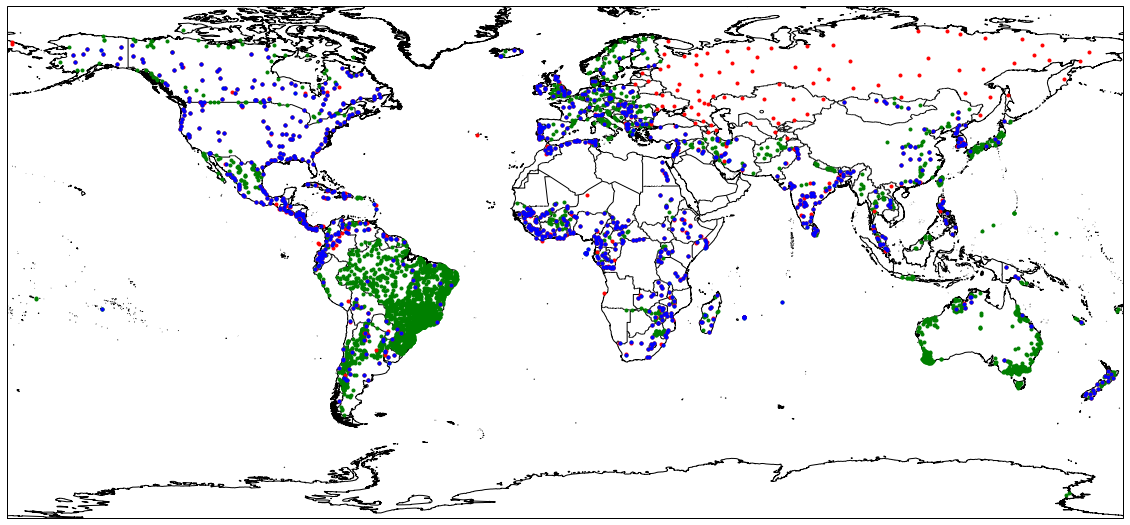

In [8]:
fig, ax = plt.subplots(figsize=(20,40),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.plot(lon_3,lat_3,'.g')
ax.plot(lon, lat,'.r')
ax.plot(lon_2,lat_2,'.b')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
ax.add_feature(cfeature.BORDERS.with_scale('10m'))

# Generamos los datos de caudal

### RVDIS

In [9]:
Caudales=pd.read_excel(path+'data\\RIVDIS.xlsx')
Localizacion['Año_inicial']=0
Localizacion['Año_final']=0

In [11]:
for i, ii in enumerate(np.unique(Caudales['POINTID'])):
    caudales_estation=pd.DataFrame()
    posi=np.where(Caudales['POINTID']==ii)
    caud=Caudales['DISCHRG'][posi[0]].values
    posi_2=np.where(caud==' ')
    caud[posi_2[0]]=np.nan 
    year=np.min(Caudales['YEAR'][posi[0]])
    year_max=np.max(Caudales['YEAR'][posi[0]])
    caudales_estation['Q(m3/s)']=caud
    time=pd.date_range(start=str(year)+'-01-01',  periods=len(caud), freq='M')
    caudales_estation.index=time
    Localizacion['Año_inicial'][i]=year
    Localizacion['Año_final'][i]=year_max
    caudales_estation.to_excel(path+'data\\'+'Estacion_'+str(ii)+'.xls')   

In [ ]:
Localizacion.to_excel(path+'comp\\Estaciones.xls')

### NCAR (Datos descargados de https://rda.ucar.edu/datasets/ds552.0/)

In [ ]:
with open(path_2+'Ncar.dat','r') as f:
    next(f) # skip first row
    df = pd.DataFrame(l.rstrip().split() for l in f).astype('float')

In [ ]:
for i, ii in enumerate(sorted(np.unique(df[0].values))):
    posi=np.where(df[0]==ii); posi=posi[0]
    years=df[1][posi].values
    time=pd.date_range(start=str(np.min(years.astype('int')))+'-01-01',  periods=len(posi)*12, freq='M')
    datos=list()
    for j in range(0, len(posi)):
        datos.append(df.loc[posi[j]][2:].values)
    caudales=pd.DataFrame(index=time)
    caudales['Q(m3/s)']=np.concatenate(datos)
    caudales.to_excel(path_2+'\\Caudales\\NCAR\\Estacion_'+str(ii.astype('int'))+'.xls')   

In [ ]:
Datos_estaciones=pd.DataFrame()

In [ ]:
n_inicio=list()
n_final=list()
n_meses_incom=list()
n_years=list()
for i, ii in enumerate(sorted(np.unique(df[0].values))):
    posi=np.where(df[0]==ii); posi=posi[0]
    years=df[1][posi].values
    n_inicio.append(np.min(years).astype('int'))
    n_final.append(np.max(years).astype('int'))
    datos=list()
    for j in range(0, len(posi)):
        datos.append(df.loc[posi[j]][2:].values)
    datos_conjunto=np.concatenate(datos)
    n_meses_incom.append(np.sum(datos_conjunto.astype('int')<0))
    n_years.append(len(np.unique(years)))
Datos_estaciones['Object-ID']=sorted(np.unique(df[0].values).astype('int'))
Datos_estaciones['Nombre rio']=Localizacion_2['river name'].values
Datos_estaciones['Año_inicio']=n_inicio   
Datos_estaciones['Año_fin']=n_final
Datos_estaciones['Meses incompletos']=n_meses_incom
Datos_estaciones['Longitud serie']=n_years
Datos_estaciones['Lon']=lon_2.values
Datos_estaciones['Lat']=lat_2.values

In [ ]:
Datos_estaciones.to_excel(path_2+'Datos_estaciones_NCAR.xls')

### NCAR 2 (Datos descargados proporcionados por IHC)

In [ ]:
with open(path_2+'Caudales_IHC.dat','r') as f:
    next(f) # skip first row
    df = pd.DataFrame(l.rstrip().split() for l in f).astype('float')

In [ ]:
#df=pd.read_csv(path_2+'Caudales_IHC.dat',delim_whitespace=True,header=None,parse_dates=[1], index_col=[0])

In [1]:
for i, ii in enumerate(sorted(np.unique(df[0].values))):
    posi=np.where(df[0]==ii); posi=posi[0]
    caudales=pd.DataFrame(columns=['Time','Q(m3/s)'])
    for j in range(0, len(posi)):
        time=pd.date_range(start=str(df.loc[posi[j]][1].astype('int'))+'-01-01',  periods=12, freq='M')
        r=pd.DataFrame(columns=['Time','Q(m3/s)'])
        r['Time']=time
        r['Q(m3/s)']=df.loc[posi[j]][2:].values
        caudales=caudales.append(r, ignore_index=True)
    caudales=caudales.set_index('Time')
    caudales.to_excel(path_2+'\\Caudales\\NCAR\\Estacion_'+str(ii.astype('int'))+'.xls')   

NameError: name 'np' is not defined

# Cargamos las estaciones que nos interesan

### RVDIS

In [9]:
OBJECT_ID_station=35011

In [10]:
caudal=pd.read_excel(path+'data\\'+'Estacion_'+str(OBJECT_ID_station)+'.xls',index_col=0,parse_dates=True)
caudal.index=pd.to_datetime(caudal.index)

FileNotFoundError: [Errno 2] No such file or directory: 'P:\\99_HIDROLOGIA\\Datos_globales\\Caudales\\RIVDIS_199\\RIVDIS_199\\data\\Estacion_35011.xls'

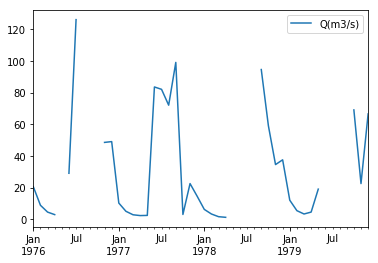

In [22]:
caudal.plot()

### NCAR 

In [ ]:
OBJECT_ID_station=9400

In [ ]:
caudal=pd.read_excel(path_2+'\\Caudales\\NCAR\\Estacion_'+str(OBJECT_ID_station)+'.xls',parse_dates=True, index_col=0)

In [ ]:
caudal.plot()

### NCAR_2 

In [8]:
OBJECT_ID_station=9368

In [9]:
caudal=pd.read_excel(path_2+'\\Caudales\\NCAR_2\\Estacion_'+str(OBJECT_ID_station)+'.xls', parse_dates=True, index_col=0)

<AxesSubplot:xlabel='Time'>

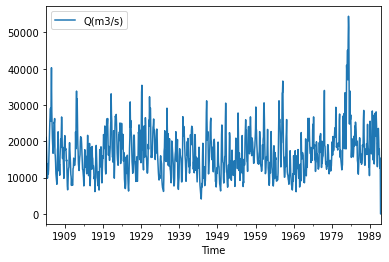

In [11]:
caudal.plot()

<AxesSubplot:xlabel='Time'>

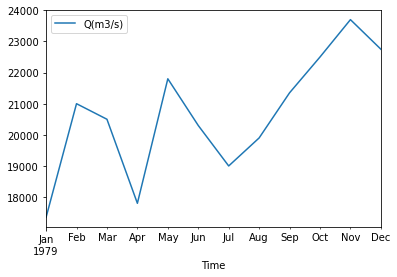

In [6]:
caudal.loc['1979':,].plot()

In [12]:
caudal.to_csv('F:\Bluefields\Aforo_9712_NCAR.csv')

In [47]:
Caudal_35304=caudal[caudal.index.year==1961]

In [50]:
Caudal_35021=caudal[caudal.index.year==1961]

In [52]:
Caudal_35304.to_excel(r'C:\Users\salvador\Desktop\Datos_killo\Estacion_35304.xlsx')
Caudal_35021.to_excel(r'C:\Users\salvador\Desktop\Datos_killo\Estacion_35021.xlsx')